In [12]:
import numpy as np
import matplotlib.pyplot as plt

def lsm(x,y):
    n = len(x)
    
    x_sum = sum(x)
    y_sum = sum(y)
    xx_sum = sum(x*x)
    xy_sum = sum(x*y)
    
    m = ((n*xy_sum) - (x_sum*y_sum)) / ((n*xx_sum) - (x_sum**2))
    c = (y_sum - (m*x_sum))/n
    
    return m,c
my_m = 5
my_c = 6

rng  = np.random.default_rng()
X = rng.random(10)
X.sort()
Y = rng.random(10)

my_m, my_b = lsm(X,Y)

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

print('My method: m= ',my_m,'  b= ', my_b)
print('Numpy method: m = ',m,'   b= ',c)

My method: m=  0.2490773712738966   b=  0.3596218871193243
Numpy method: m =  0.24907737127389687    b=  0.35962188711932414


The largest residual is  -1.0113253232678883  at point  0.79
The smallest residual is -0.0004417176199709161  at point  0.13
Original Equation: y= 5 x+ 8
My Equation: y= 5.038454556828551 x+ 7.986490272744193
Numpy Equation: y= 5.038454556828548 x+ 7.986490272744191


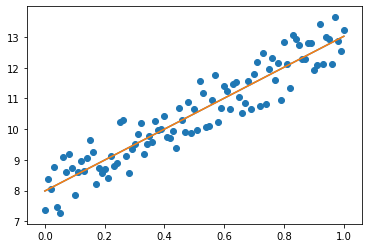

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def lsm(x,y):
    n = len(x)
    
    x_sum = sum(x)
    y_sum = sum(y)
    xx_sum = sum(x*x)
    xy_sum = sum(x*y)
    
    m = ((n*xy_sum) - (x_sum*y_sum)) / ((n*xx_sum) - (x_sum**2))
    c = (y_sum - (m*x_sum))/n
    return m,c

m_true = 5
b_true = 8

X = np.arange(0,1.01,0.01)
rng  = np.random.default_rng()
b = rng.random(len(X))
sign = rng.choice([-1,1], len(X))
Y = m_true*X + b_true + b*sign

my_m, my_b = lsm(X,Y)
my_Y = my_m*X + my_b

A = np.vstack([X, np.ones(len(X))]).T
m_np, b_np = np.linalg.lstsq(A, Y, rcond=None)[0]
np_Y = m_np*X + b_np

res = Y - my_Y
max_ = np.argmax(np.abs(res))
min_ = np.argmin(np.abs(res))

print('The largest residual is ', res[max_], ' at point ', X[max_])
print('The smallest residual is', res[min_], ' at point ', X[min_])
print('Original Equation: y=',m_true,'x+',b_true)
print('My Equation: y=',my_m,'x+',my_b)
print('Numpy Equation: y=',m_np,'x+',b_np)
plt.scatter(X,Y)
plt.plot(X, my_Y)
plt.plot(X, np_Y)
plt.show()